# (Optional) Colab Setup
If you aren't using Colab, you can delete the following code cell. This is just to help students with mounting to Google Drive to access the other .py files and downloading the data, which is a little trickier on Colab than on your local machine using Jupyter. 

In [1]:
# # you will be prompted with a window asking to grant permissions
# from google.colab import drive
# drive.mount("/content/drive")

In [2]:
# # fill in the path in your Google Drive in the string below. Note: do not escape slashes or spaces
# import os
# datadir = "/Users/ambasht2/Desktop/Spring 2026/CS 444/assignment1_sp26_starter_code"
# # if not os.path.exists(datadir):
# #   !ln -s "/content/drive/My Drive/YOUR PATH HERE/assignment1/" $datadir
# os.chdir(datadir)
# !pwd

In [3]:
# # downloading Fashion-MNIST
# import os
# os.chdir(os.path.join(datadir,"fashion-mnist/"))
# !chmod +x ./get_data.sh
# !./get_data.sh
# os.chdir(datadir)

# Imports

In [1]:
import random
import numpy as np
from data_process import get_FASHION_data, get_RICE_data
from scipy.spatial import distance
from models import Perceptron, SVM, Softmax, Logistic
from kaggle_submission import output_submission_csv

%matplotlib inline

# For auto-reloading external modules
# See http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

# Loading Fashion-MNIST

In the following cells we determine the number of images for each split and load the images.
<br /> 
TRAIN_IMAGES + VAL_IMAGES = (0, 60000]
, TEST_IMAGES = 10000

In [2]:
# You can change these numbers for experimentation
# For submission we will use the default values 
TRAIN_IMAGES = 50000
VAL_IMAGES = 10000
normalize = True

In [3]:
data = get_FASHION_data(TRAIN_IMAGES, VAL_IMAGES, normalize=normalize)
X_train_fashion, y_train_fashion = data['X_train'], data['y_train']
X_val_fashion, y_val_fashion = data['X_val'], data['y_val']
X_test_fashion, y_test_fashion = data['X_test'], data['y_test']
n_class_fashion = len(np.unique(y_test_fashion))

# Loading Rice

In [4]:
# loads train / test / val splits of 80%, 20%, 20% 
data = get_RICE_data()
X_train_RICE, y_train_RICE = data['X_train'], data['y_train']
X_val_RICE, y_val_RICE = data['X_val'], data['y_val']
X_test_RICE, y_test_RICE = data['X_test'], data['y_test']
n_class_RICE = len(np.unique(y_test_RICE))

print("Number of train samples: ", X_train_RICE.shape[0])
print("Number of val samples: ", X_val_RICE.shape[0])
print("Number of test samples: ", X_test_RICE.shape[0])

Number of train samples:  10911
Number of val samples:  3637
Number of test samples:  3637


### Get Accuracy

This function computes how well your model performs using accuracy as a metric.

In [5]:
def get_acc(pred, y_test):
    return np.sum(y_test == pred) / len(y_test) * 100

# Perceptron

Perceptron has 2 hyperparameters, "learning rate" and "number of epochs" that you can experiment with:
### Hyperparameter 1: Learning rate
The learning rate controls how much we change the current weights of the classifier during each update. We set it at a default value of 0.5, but you should experiment with different values. Here is a guide to help you find a right learning rate: 
- Try values ranging from 0.0005 to 5.0 to see the impact on model accuracy. 
- If the loss oscillates a lot or the loss diverges, the learning rate may be too high. Try decreasing it by a factor of 10 (e.g. from 0.5 to 0.05). 
- If the loss decreases very slowly, the learning rate may be too low and the training can take a long time. Try increasing it by a factor of 10.
- You can also try adding a learning rate decay to slowly reduce the learning rate over each training epoch. For example, multiply the learning rate by 0.95 after each epoch.
- Plot training and validation accuracy over epochs for different learning rates. This will help you visualize the impact of the learning rate.
- [Here](https://towardsdatascience.com/https-medium-com-dashingaditya-rakhecha-understanding-learning-rate-dd5da26bb6de) is a detailed guide to learning rate.

### Hyperparameter 2: Number of Epochs
- An epoch is a complete iterative pass over the training dataset. During an epoch we predict a label using the classifier and then update the weights of the classifier according to the perceptron update rule for each sample in the training set. 
- By observing the training and validation accuracy graphs, you can determine if the model has converged or not. Try increasing the number of epochs if the model is not converging or has low accuracy. 
- You should try different values for the number of training epochs and report your results.

In this section, you will implement the Perceptron classifier in the **models/perceptron.py** script.

The following code: 
- Creates an instance of the Perceptron classifier class 
- An instance of the Perceptron class is trained on the training data using its train method.
- We use the predict method to find the training accuracy as well as the testing accuracy


## Train Perceptron on Fashion-MNIST

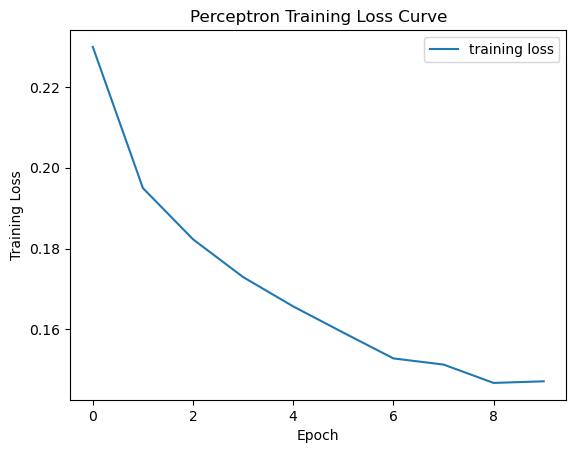

In [6]:
lr = 0.8
n_epochs = 10
percept_fashion = Perceptron(n_class_fashion, lr, n_epochs, 2.0)

# - Refer to hints in the train method of the Perceptron class in "models/perceptron.py"
percept_fashion.train(X_train_fashion, y_train_fashion)

percept_fashion.plot_training_loss()

In [18]:
def add_bias(X):
    if X.ndim == 2 and np.allclose(X[:, -1], 1):
        return X
    return np.hstack([X, np.ones((X.shape[0], 1))])

X_train_fashion_bias = add_bias(X_train_fashion)
X_val_fashion_bias = add_bias(X_val_fashion)
X_test_fashion_bias = add_bias(X_test_fashion)
# X_train_fashion_bias = add_bias(X_train_fashion)
# pred_percept = percept_fashion.predict(X_train_fashion_bias)
# print('The training accuracy is given by: %f' % (get_acc(pred_percept, y_train_fashion)))

In [8]:
# param_grid = {
#     'lr': [0.01, 0.1, 0.5, 0.8],
#     'epochs': [10, 50, 100, 500]
# }

# best_acc = -1
# best_params = None
# best_model = None

# X_train_fashion_bias = add_bias(X_train_fashion)
# X_val_fashion_bias = add_bias(X_val_fashion)
# X_test_fashion_bias = add_bias(X_test_fashion)
# for lr in param_grid['lr']:
#     for epochs in param_grid['epochs']:
#         percept = Perceptron(n_class_fashion, lr, epochs)
#         percept.train(X_train_fashion_bias, y_train_fashion)
#         pred = percept.predict(X_val_fashion_bias)
#         acc = get_acc(pred, y_val_fashion)
        
#         print(f"lr={lr}, epochs={epochs}: {acc:.4f}%")
#         if acc > best_acc:
#             best_acc = acc
#             best_params = {'lr': lr, 'epochs': epochs}
#             best_model = percept

# print("\nBest parameters:", best_params)
# print(f"Best validation accuracy: {best_acc:.4f}%")
# best_model.plot_training_loss() 

lr=0.001, epochs=5: 82.4000%, decay_rate=1.0
lr=0.001, epochs=5: 81.5700%, decay_rate=1.5
lr=0.001, epochs=5: 81.4800%, decay_rate=2.0
lr=0.001, epochs=5: 82.7100%, decay_rate=2.5
lr=0.001, epochs=5: 79.7400%, decay_rate=3.0
lr=0.001, epochs=10: 82.3600%, decay_rate=1.0
lr=0.001, epochs=10: 81.9200%, decay_rate=1.5
lr=0.001, epochs=10: 81.7600%, decay_rate=2.0
lr=0.001, epochs=10: 81.4300%, decay_rate=2.5
lr=0.001, epochs=10: 80.9100%, decay_rate=3.0
lr=0.001, epochs=15: 82.3600%, decay_rate=1.0
lr=0.001, epochs=15: 82.0800%, decay_rate=1.5
lr=0.001, epochs=15: 81.4100%, decay_rate=2.0
lr=0.001, epochs=15: 81.4800%, decay_rate=2.5
lr=0.001, epochs=15: 80.9900%, decay_rate=3.0
lr=0.001, epochs=20: 82.3600%, decay_rate=1.0
lr=0.001, epochs=20: 82.0900%, decay_rate=1.5
lr=0.001, epochs=20: 81.3400%, decay_rate=2.0
lr=0.001, epochs=20: 81.2500%, decay_rate=2.5
lr=0.001, epochs=20: 81.0000%, decay_rate=3.0
lr=0.001, epochs=25: 82.3600%, decay_rate=1.0
lr=0.001, epochs=25: 82.0900%, decay_ra

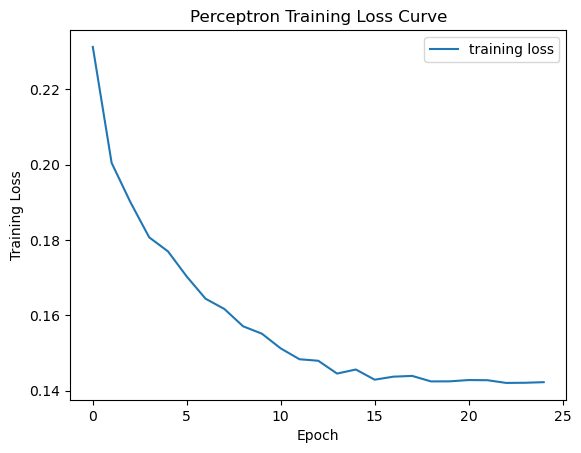

In [9]:
param_grid_fine = {
    'lr': [0.001, 0.0025, 0.005, 0.01, 0.05, 0.075, 0.1],
    'epochs': [5, 10, 15, 20, 25, 30, 35], 
    'decay_rate': [1.0, 1.5, 2.0, 2.5, 3.0]
}

best_acc_fine = -1
best_params_fine = None
best_model_fine = None
models = []
for lr in param_grid_fine['lr']:
    if lr < 0.01: # then dont run for more than 25 epochs
        for epochs in [5, 10, 15, 20, 25]:
            for decay_rate in param_grid_fine['decay_rate']:
                percept = Perceptron(n_class_fashion, lr, epochs, decay_rate)
                percept.train(X_train_fashion_bias, y_train_fashion)
                pred = percept.predict(X_val_fashion_bias)
                acc = get_acc(pred, y_val_fashion)
                models.append(percept)
                print(f"lr={lr}, epochs={epochs}: {acc:.4f}%, decay_rate={decay_rate}")
                if acc > best_acc_fine:
                    best_acc_fine = acc
                    best_params_fine = {'lr': lr, 'epochs': epochs, 'decay_rate': decay_rate}
                best_model_fine = percept
    else:
        for epochs in [5, 10, 15, 20, 25, 30, 35]:
            for decay_rate in param_grid_fine['decay_rate']:
                percept = Perceptron(n_class_fashion, lr, epochs, decay_rate)
                percept.train(X_train_fashion_bias, y_train_fashion)
                pred = percept.predict(X_val_fashion_bias)
                acc = get_acc(pred, y_val_fashion)
                models.append(percept)
                print(f"lr={lr}, epochs={epochs}: {acc:.4f}%, decay_rate={decay_rate}")
                if acc > best_acc_fine:
                    best_acc_fine = acc
                    best_params_fine = {'lr': lr, 'epochs': epochs, 'decay_rate': decay_rate}
                    best_model_fine = percept

print("\nBest parameters (fine search):", best_params_fine)
print(f"Best validation accuracy (fine search): {best_acc_fine:.4f}%")
best_model_fine.plot_training_loss()

In [ ]:
best_lr_perceptron = 0.001
best_epochs_perceptron = 5
best_decay_perceptron = 2.5

best_model_test_set_softmax = Perceptron(n_class_fashion, best_lr_perceptron, best_epochs_perceptron, best_decay_perceptron)
best_model_test_set_softmax.train(X_train_fashion_bias, y_train_fashion)

print('')
print('Best parameters for test set: lr=%f, epochs=%d, decay_rate=%f' % (best_lr_perceptron, best_epochs_perceptron, best_decay_perceptron))
print('The training accuracy is given by: %f' % (get_acc(best_model_test_set_softmax.predict(X_train_fashion_bias), y_train_fashion)))
print('The validation accuracy is given by: %f' % (get_acc(best_model_test_set_softmax.predict(X_val_fashion_bias), y_val_fashion)))
print('The testing accuracy is given by: %f' % (get_acc(best_model_test_set_softmax.predict(X_test_fashion_bias), y_test_fashion)))

The training accuracy is given by: 85.524000
The validation accuracy is given by: 82.710000
The testing accuracy is given by: 81.500000


In [14]:
model_baseline_accuracy = 81.6
for model in models:
    pred = model.predict(X_test_fashion_bias)
    acc = get_acc(pred, y_test_fashion)
    #print(f"Test accuracy: {acc:.4f}%")
   
    if acc > model_baseline_accuracy:
        best_model_test_set = model
        print('Accuracy on test set: %f' % acc)

Accuracy on test set: 81.640000


In [12]:
# param_grid_finer = {
#     'lr': [0.01, 0.0125, 0.015, 0.0175, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06, 0.065, 0.075, 0.08, 0.085, 0.09, 0.095, 0.1],
#     'epochs': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
# }

# best_acc_finer = -1
# best_params_finer = best_params_fine.copy()
# best_model_finer = best_model_fine
# models_finer = []
# for lr in param_grid_finer['lr']:
#     for epochs in param_grid_finer['epochs']:
#         percept = Perceptron(n_class_fashion, lr, epochs)
#         percept.train(X_train_fashion_bias, y_train_fashion)
#         pred = percept.predict(X_val_fashion_bias)
#         acc = get_acc(pred, y_val_fashion)
#         models_finer.append(percept)
#         print(f"lr={lr}, epochs={epochs}: {acc:.4f}%")
#         if acc > best_acc_fine:
#             best_acc_finer = acc
#             best_params_finer = {'lr': lr, 'epochs': epochs}
#             best_model_finer = percept

In [ ]:
# model_baseline_accuracy = 81.00
# best_test_set_acc = -1
# for model in models_finer:
#     pred = model.predict(X_test_fashion_bias)
#     acc = get_acc(pred, y_test_fashion)
#     if acc > model_baseline_accuracy:
#         print('Accuracy on test set: %f' % acc)
#         if acc > best_test_set_acc:
#             best_test_set_acc = acc
#             best_model_test_set = model

Accuracy on test set: 81.180000
Accuracy on test set: 81.180000
Accuracy on test set: 81.070000
Accuracy on test set: 81.190000


### Validate Perceptron on Fashion-MNIST

In [15]:
X_val_fashion_bias = add_bias(X_val_fashion)



pred_percept = best_model_fine.predict(X_val_fashion_bias)
print('The validation accuracy is given by: %f' % (get_acc(pred_percept, y_val_fashion)))

The validation accuracy is given by: 81.020000


### Test Perceptron on Fashion-MNIST

In [17]:
X_test_fashion_bias = add_bias(X_test_fashion)
pred_percept = best_model_test_set.predict(X_test_fashion_bias)
print('The testing accuracy is given by: %f' % (get_acc(pred_percept, y_test_fashion)))

The testing accuracy is given by: 81.640000


In [18]:
# best_test_acc = 81
# print(f"Best model test accuracy: {best_test_acc:.4f}%")
# for model in models_finer:
#     X_test_fashion_bias = add_bias(X_test_fashion)
#     pred_percept = model.predict(X_test_fashion_bias)
#     # print(f"Model {models.index(model)} test accuracy: {get_acc(pred_percept, y_test_fashion):.4f}%")
#     if get_acc(pred_percept, y_test_fashion) > best_test_acc:
#         index = models_finer.index(model)
#         print(f"Model test accuracy: {get_acc(pred_percept, y_test_fashion):.4f}%")
#         best_model_test_set = model
#         #print(f"Model {models.index(model)} test accuracy: {get_acc(pred_percept, y_test_fashion):.4f}%")



### Perceptron_Fashion-MNIST Kaggle Submission

Once you are satisfied with your solution and test accuracy, output a file to submit your test set predictions to the Kaggle for Assignment 1 Fashion-MNIST. Use the following code to do so:

In [19]:
output_submission_csv('kaggle/perceptron_submission_fashion.csv', best_model_test_set.predict(X_test_fashion_bias))

## Train Perceptron on Rice

In [ ]:
lr = 0.5
n_epochs = 100
decay_rate = 0.0
percept_RICE = Perceptron(n_class_RICE, lr, n_epochs, decay_rate)
percept_RICE.train(X_train_RICE, y_train_RICE)

In [7]:
pred_percept = percept_RICE.predict(X_train_RICE)
print('The training accuracy is given by: %f' % (get_acc(pred_percept, y_train_RICE)))

The training accuracy is given by: 99.917514


### Validate Perceptron on Rice

In [8]:
pred_percept = percept_RICE.predict(X_val_RICE)
print('The validation accuracy is given by: %f' % (get_acc(pred_percept, y_val_RICE)))

The validation accuracy is given by: 99.890019


### Test Perceptron on Rice

In [9]:
pred_percept = percept_RICE.predict(X_test_RICE)
print('The testing accuracy is given by: %f' % (get_acc(pred_percept, y_test_RICE)))

The testing accuracy is given by: 99.862524


# Support Vector Machines (with SGD)

Next, you will implement a "soft margin" SVM. In this formulation you will maximize the margin between positive and negative training examples and penalize margin violations using a hinge loss.

We will optimize the SVM loss using SGD. This means you must compute the loss function with respect to model weights. You will use this gradient to update the model weights.

SVM optimized with SGD has 3 hyperparameters that you can experiment with:
- **Learning rate** - similar to as defined above in Perceptron, this parameter scales by how much the weights are changed according to the calculated gradient update. 
- **Epochs** - similar to as defined above in Perceptron.
- **Regularization constant** - Hyperparameter to determine the strength of regularization. In this case it is a coefficient on the term which maximizes the margin. You could try different values. The default value is set to 0.05.

You will implement the SVM using SGD in the **models/svm.py**

The following code: 
- Creates an instance of the SVM classifier class 
- The train function of the SVM class is trained on the training data
- We use the predict function to find the training accuracy as well as the testing accuracy

## Train SVM on Fashion-MNIST

In [6]:
# Adjust the following three hyperparameters to achieve the best accuracy:
lr = 0.5
n_epochs = 10
reg_const = 0.001

svm_fashion = SVM(n_class_fashion, lr, n_epochs, reg_const)

# Refer to hints in the calculate_gradient and train methods of the SVM class in "models/svm.py"
svm_fashion.train(X_train_fashion, y_train_fashion)

In [7]:
# grid search over SVM parameters
param_grid_svm = {
    'lr': [0.001, 0.01, 0.1, 0.5, 1.0],
    'epochs': [10, 20, 50, 100],
    'reg_const': [0.0001, 0.001, 0.01, 0.1, 0.5]
}

best_acc_svm = -1
best_params_svm = None
best_model_svm = None

for lr in param_grid_svm['lr']:
    for reg_const in param_grid_svm['reg_const']:
        for epochs in param_grid_svm['epochs']:
            svm = SVM(n_class_fashion, lr, epochs, reg_const)
            svm.train(X_train_fashion, y_train_fashion)
            pred = svm.predict(X_val_fashion)
            acc = get_acc(pred, y_val_fashion)
            
            print(f"lr={lr}, epochs={epochs}, reg_const={reg_const}: {acc:.4f}%")
            if acc > best_acc_svm:
                best_acc_svm = acc
                best_params_svm = {'lr': lr, 'epochs': epochs, 'reg_const': reg_const}
                best_model_svm = svm

print("\nBest SVM parameters:", best_params_svm)
print(f"Best SVM validation accuracy: {best_acc_svm:.4f}%")

lr=0.001, epochs=10, reg_const=0.0001: 76.4700%
lr=0.001, epochs=20, reg_const=0.0001: 81.0400%
lr=0.001, epochs=50, reg_const=0.0001: 79.4900%
lr=0.001, epochs=100, reg_const=0.0001: 67.9500%
lr=0.001, epochs=10, reg_const=0.001: 74.9000%
lr=0.001, epochs=20, reg_const=0.001: 81.7900%
lr=0.001, epochs=50, reg_const=0.001: 81.4500%
lr=0.001, epochs=100, reg_const=0.001: 74.3900%
lr=0.001, epochs=10, reg_const=0.01: 77.8000%
lr=0.001, epochs=20, reg_const=0.01: 80.2600%
lr=0.001, epochs=50, reg_const=0.01: 80.2700%
lr=0.001, epochs=100, reg_const=0.01: 65.8500%
lr=0.001, epochs=10, reg_const=0.1: 74.1200%
lr=0.001, epochs=20, reg_const=0.1: 77.6500%
lr=0.001, epochs=50, reg_const=0.1: 78.9700%
lr=0.001, epochs=100, reg_const=0.1: 69.2200%
lr=0.001, epochs=10, reg_const=0.5: 73.7500%
lr=0.001, epochs=20, reg_const=0.5: 81.3800%
lr=0.001, epochs=50, reg_const=0.5: 80.2400%
lr=0.001, epochs=100, reg_const=0.5: 80.6900%
lr=0.01, epochs=10, reg_const=0.0001: 76.9200%
lr=0.01, epochs=20, reg_

In [14]:
# Fine-grained grid search around best SVM parameters
param_grid_svm_fine = {
    'lr': [best_params_svm['lr'] * factor for factor in [0.5, 0.75, 1.0, 1.25, 1.5]],
    'epochs': [max(1, best_params_svm['epochs'] - 10), best_params_svm['epochs'] - 5, best_params_svm['epochs'], best_params_svm['epochs'] + 5, best_params_svm['epochs'] + 10],
    'reg_const': [best_params_svm['reg_const'] * factor for factor in [0.5, 0.75, 1.0, 1.25, 1.5]]
}

best_acc_svm_fine = best_acc_svm
best_params_svm_fine = best_params_svm.copy()
best_model_svm_fine = best_model_svm
models = []
for lr in param_grid_svm_fine['lr']:
    for epochs in param_grid_svm_fine['epochs']:
        for reg_const in param_grid_svm_fine['reg_const']:
            svm = SVM(n_class_fashion, lr, epochs, reg_const)
            svm.train(X_train_fashion, y_train_fashion)
            pred = svm.predict(X_val_fashion)
            acc = get_acc(pred, y_val_fashion)
            models.append(svm)
            print(f"lr={lr}, epochs={epochs}, reg_const={reg_const}: {acc:.4f}%")
            if acc > best_acc_svm_fine:
                best_acc_svm_fine = acc
                best_params_svm_fine = {'lr': lr, 'epochs': epochs, 'reg_const': reg_const}
                best_model_svm_fine = svm

print("\nBest SVM parameters (fine search):", best_params_svm_fine)
print(f"Best SVM validation accuracy (fine search): {best_acc_svm_fine:.4f}%")

lr=0.005, epochs=10, reg_const=0.005: 76.3100%
lr=0.005, epochs=10, reg_const=0.0075: 79.9900%
lr=0.005, epochs=10, reg_const=0.01: 74.5200%
lr=0.005, epochs=10, reg_const=0.0125: 75.2800%
lr=0.005, epochs=10, reg_const=0.015: 74.7500%
lr=0.005, epochs=15, reg_const=0.005: 71.9500%
lr=0.005, epochs=15, reg_const=0.0075: 66.5000%
lr=0.005, epochs=15, reg_const=0.01: 67.4000%
lr=0.005, epochs=15, reg_const=0.0125: 63.3000%
lr=0.005, epochs=15, reg_const=0.015: 74.6000%
lr=0.005, epochs=20, reg_const=0.005: 80.9500%
lr=0.005, epochs=20, reg_const=0.0075: 81.0600%
lr=0.005, epochs=20, reg_const=0.01: 81.3500%
lr=0.005, epochs=20, reg_const=0.0125: 81.1900%
lr=0.005, epochs=20, reg_const=0.015: 80.9600%
lr=0.005, epochs=25, reg_const=0.005: 76.0700%
lr=0.005, epochs=25, reg_const=0.0075: 74.8200%
lr=0.005, epochs=25, reg_const=0.01: 78.7500%
lr=0.005, epochs=25, reg_const=0.0125: 76.3600%
lr=0.005, epochs=25, reg_const=0.015: 75.5100%
lr=0.005, epochs=30, reg_const=0.005: 79.1900%
lr=0.005,

In [10]:
best_model = SVM(n_class_fashion, best_params_svm_fine['lr'], best_params_svm_fine['epochs'], best_params_svm_fine['reg_const'] )
best_model.train(X_train_fashion, y_train_fashion)
# trainign accuracy
pred = best_model.predict(X_train_fashion)
print('The training accuracy is given by: %f' % (get_acc(pred, y_train_fashion)))

# validation accuracy
pred = best_model.predict(X_val_fashion)
print('The validation accuracy is given by: %f' % (get_acc(pred, y_val_fashion)))

# test accuracy
pred = best_model.predict(X_test_fashion)
print('The testing accuracy is given by: %f' % (get_acc(pred, y_test_fashion)))

The training accuracy is given by: 84.502000
The validation accuracy is given by: 82.150000
The testing accuracy is given by: 81.140000


In [15]:
test_set_baseline_accuracy = 81.22
for model in models:
    pred = model.predict(X_test_fashion)
    acc = get_acc(pred, y_test_fashion)
    #print(f"Test accuracy: {acc:.4f}%")
   
    if acc > test_set_baseline_accuracy:
        best_model_test_set = model
        print('Accuracy on test set: %f' % acc)



Accuracy on test set: 81.280000


In [16]:
pred_svm = best_model_test_set.predict(X_train_fashion)
print('The training accuracy is given by: %f' % (get_acc(pred_svm, y_train_fashion)))

The training accuracy is given by: 84.778000


### Validate SVM on Fashion-MNIST

In [17]:
pred_svm = best_model_test_set.predict(X_val_fashion)
print('The validation accuracy is given by: %f' % (get_acc(pred_svm, y_val_fashion)))

The validation accuracy is given by: 82.370000


### Test SVM on Fashion-MNIST

In [18]:
pred_svm = best_model_test_set.predict(X_test_fashion)
print('The testing accuracy is given by: %f' % (get_acc(pred_svm, y_test_fashion)))

The testing accuracy is given by: 81.280000


### SVM_Fashion-MNIST Kaggle Submission

Once you are satisfied with your solution and test accuracy output a file to submit your test set predictions to the Kaggle for Assignment 1 Fashion-MNIST. Use the following code to do so:

In [19]:
output_submission_csv('kaggle/svm_submission_fashion.csv', best_model_test_set.predict(X_test_fashion))

## Train SVM on Rice

In [26]:
# Adjust the following three hyperparameters to achieve the best accuracy: 
lr = 0.5
n_epochs = 10
reg_const = 0.05

svm_RICE = SVM(n_class_RICE, lr, n_epochs, reg_const)
svm_RICE.train(X_train_RICE, y_train_RICE)

In [27]:
params = {
    'lr': [0.001, 0.01, 0.1, 0.5, 1.0],
    'epochs': [10, 20, 50, 100, 500],
    'reg_const': [0.0001, 0.001, 0.01, 0.1, 0.5]
}

best_acc_svm_RICE = -1
best_params_svm_RICE = None
best_model_svm_RICE = None

for lr in params['lr']:
    for reg_const in params['reg_const']:
        for epochs in params['epochs']:
            svm = SVM(n_class_RICE, lr, epochs, reg_const)
            svm.train(X_train_RICE, y_train_RICE)
            pred = svm.predict(X_val_RICE)
            acc = get_acc(pred, y_val_RICE)
            
            print(f"lr={lr}, epochs={epochs}, reg_const={reg_const}: {acc:.4f}%")
            if acc > best_acc_svm_RICE:
                best_acc_svm_RICE = acc
                best_params_svm_RICE = {'lr': lr, 'epochs': epochs, 'reg_const': reg_const}
                best_model_svm_RICE = svm
            

lr=0.001, epochs=10, reg_const=0.0001: 79.8735%
lr=0.001, epochs=20, reg_const=0.0001: 77.0965%
lr=0.001, epochs=50, reg_const=0.0001: 88.3970%
lr=0.001, epochs=100, reg_const=0.0001: 99.8350%
lr=0.001, epochs=500, reg_const=0.0001: 99.7525%
lr=0.001, epochs=10, reg_const=0.001: 75.4743%
lr=0.001, epochs=20, reg_const=0.001: 50.0687%
lr=0.001, epochs=50, reg_const=0.001: 60.2420%
lr=0.001, epochs=100, reg_const=0.001: 99.8350%
lr=0.001, epochs=500, reg_const=0.001: 99.8625%
lr=0.001, epochs=10, reg_const=0.01: 73.2747%
lr=0.001, epochs=20, reg_const=0.01: 83.0905%
lr=0.001, epochs=50, reg_const=0.01: 91.0916%
lr=0.001, epochs=100, reg_const=0.01: 99.8075%
lr=0.001, epochs=500, reg_const=0.01: 99.8075%
lr=0.001, epochs=10, reg_const=0.1: 77.4265%
lr=0.001, epochs=20, reg_const=0.1: 64.0088%
lr=0.001, epochs=50, reg_const=0.1: 91.6415%
lr=0.001, epochs=100, reg_const=0.1: 86.3899%
lr=0.001, epochs=500, reg_const=0.1: 99.8900%
lr=0.001, epochs=10, reg_const=0.5: 76.0792%
lr=0.001, epochs=

In [16]:
best_params_svm_RICE  = {'lr': 0.5, 'epochs': 500, 'reg_const': 0.001}
best_svm_test_set = SVM(n_class_RICE, best_params_svm_RICE['lr'], best_params_svm_RICE['epochs'], best_params_svm_RICE['reg_const'])
best_svm_test_set.train(X_train_RICE, y_train_RICE)

pred_svm_train = best_svm_test_set.predict(X_train_RICE)
pred_svm_val = best_svm_test_set.predict(X_val_RICE)
pred_svm_test = best_svm_test_set.predict(X_test_RICE)

print('The training accuracy is given by: %f' % (get_acc(pred_svm_train, y_train_RICE)))    
print('The validation accuracy is given by: %f' % (get_acc(pred_svm_val, y_val_RICE)))
print('The testing accuracy is given by: %f' % (get_acc(pred_svm_test, y_test_RICE)))

The training accuracy is given by: 99.092659
The validation accuracy is given by: 99.257630
The testing accuracy is given by: 99.065164


In [7]:
pred_svm = best_model_svm_RICE.predict(X_train_RICE)
print('The training accuracy is given by: %f' % (get_acc(pred_svm, y_train_RICE)))

The training accuracy is given by: 99.945010


### Validate SVM on Rice

In [ ]:
pred_svm = best_model_svm_RICE.predict(X_val_RICE)
print('The validation accuracy is given by: %f' % (get_acc(pred_svm, y_val_RICE)))

The validation accuracy is given by: 66.538356


## Test SVM on Rice

In [8]:
pred_svm = best_model_svm_RICE.predict(X_test_RICE)
print('The testing accuracy is given by: %f' % (get_acc(pred_svm, y_test_RICE)))

The testing accuracy is given by: 99.917514


# Softmax Classifier (with SGD)

Next, you will train a Softmax classifier. This classifier consists of a linear function of the input data followed by a softmax function which outputs a vector of dimension C (number of classes) for each data point. Each entry of the softmax output vector corresponds to a confidence in one of the C classes, and like a probability distribution, the entries of the output vector sum to 1. We use a cross-entropy loss on this sotmax output to train the model. 

Check the following link as an additional resource on softmax classification: http://cs231n.github.io/linear-classify/#softmax

Once again we will train the classifier with SGD. This means you need to compute the gradients of the softmax cross-entropy loss function according to the weights and update the weights using this gradient. Check the following link to help with implementing the gradient updates: https://deepnotes.io/softmax-crossentropy

The softmax classifier has 3 hyperparameters that you can experiment with:
- **Learning rate** - As above, this controls how much the model weights are updated with respect to their gradient.
- **Number of Epochs** - As described for perceptron.
- **Regularization constant** - Hyperparameter to determine the strength of regularization. In this case, we minimize the L2 norm of the model weights as regularization, so the regularization constant is a coefficient on the L2 norm in the combined cross-entropy and regularization objective.

You will implement a softmax classifier using SGD in the **models/softmax.py**

The following code: 
- Creates an instance of the Softmax classifier class 
- The train function of the Softmax class is trained on the training data
- We use the predict function to find the training accuracy as well as the testing accuracy

## Train Softmax on Fashion-MNIST

In [ ]:
lr = 0.1
n_epochs = 200
reg_const = 0.001

softmax_fashion = Softmax(n_class_fashion, lr, n_epochs, reg_const)

# Refer to hints in the calculate_gradient and train methods of the Softmax class in "models/softmax.py"
softmax_fashion.train(X_train_fashion, y_train_fashion)

In [ ]:
# Grid search over Softmax parameters
param_grid_softmax = {
    'lr': [0.001, 0.01, 0.1, 0.5, 1.0],
    'epochs': [100, 500, 1000],
    'reg_const': [0.0001, 0.001, 0.01, 0.1, 0.5]
}

best_acc_softmax = -1
best_params_softmax = None
best_model_softmax = None

for lr in param_grid_softmax['lr']:
    for reg_const in param_grid_softmax['reg_const']:
        for epochs in param_grid_softmax['epochs']:
            softmax = Softmax(n_class_fashion, lr, epochs, reg_const)
            softmax.train(X_train_fashion, y_train_fashion)
            pred = softmax.predict(X_val_fashion)
            acc = get_acc(pred, y_val_fashion)
            
            print(f"lr={lr}, epochs={epochs}, reg_const={reg_const}: {acc:.4f}%")
            if acc > best_acc_softmax:
                best_acc_softmax = acc
                best_params_softmax = {'lr': lr, 'epochs': epochs, 'reg_const': reg_const}
                best_model_softmax = softmax

print("\nBest Softmax parameters:", best_params_softmax)
print(f"Best Softmax validation accuracy: {best_acc_softmax:.4f}%")

In [ ]:
# Fine-grained grid search around best Softmax parameters
param_grid_softmax_fine = {
    'lr': [0.8, 0.9, 1.0, 1.1, 1.2, 1.3],
    'epochs': [80, 90, 100, 110, 120],
    'reg_const': [0.00005, 0.00008, 0.0001, 0.00012, 0.00015, 0.0002]
}

best_acc_softmax_fine = best_acc_softmax
best_params_softmax_fine = best_params_softmax.copy()
best_model_softmax_fine = best_model_softmax

for lr in param_grid_softmax_fine['lr']:
    for reg_const in param_grid_softmax_fine['reg_const']:
        for epochs in param_grid_softmax_fine['epochs']:
            softmax = Softmax(n_class_fashion, lr, epochs, reg_const)
            softmax.train(X_train_fashion, y_train_fashion)
            pred = softmax.predict(X_val_fashion)
            acc = get_acc(pred, y_val_fashion)
            
            print(f"lr={lr}, epochs={epochs}, reg_const={reg_const}: {acc:.4f}%")
            if acc > best_acc_softmax_fine:
                best_acc_softmax_fine = acc
                best_params_softmax_fine = {'lr': lr, 'epochs': epochs, 'reg_const': reg_const}
                best_model_softmax_fine = softmax

print("\nBest Softmax parameters (fine search):", best_params_softmax_fine)
print(f"Best Softmax validation accuracy (fine search): {best_acc_softmax_fine:.4f}%")

lr=0.8, epochs=80, reg_const=5e-05: 76.6500%
lr=0.8, epochs=90, reg_const=5e-05: 76.2600%
lr=0.8, epochs=100, reg_const=5e-05: 78.0000%
lr=0.8, epochs=110, reg_const=5e-05: 73.5100%
lr=0.8, epochs=120, reg_const=5e-05: 80.4900%
lr=0.8, epochs=80, reg_const=8e-05: 80.8800%
lr=0.8, epochs=90, reg_const=8e-05: 79.4400%
lr=0.8, epochs=100, reg_const=8e-05: 80.8300%
lr=0.8, epochs=110, reg_const=8e-05: 82.5800%
lr=0.8, epochs=120, reg_const=8e-05: 79.4500%
lr=0.8, epochs=80, reg_const=0.0001: 78.8700%
lr=0.8, epochs=90, reg_const=0.0001: 80.8800%
lr=0.8, epochs=100, reg_const=0.0001: 74.0000%
lr=0.8, epochs=110, reg_const=0.0001: 80.5100%
lr=0.8, epochs=120, reg_const=0.0001: 78.9900%
lr=0.8, epochs=80, reg_const=0.00012: 80.5900%


In [23]:
pred_softmax = best_model_softmax.predict(X_train_fashion)
print('The training accuracy is given by: %f' % (get_acc(pred_softmax, y_train_fashion)))

The training accuracy is given by: 85.704000


### Validate Softmax on Fashion-MNIST

In [24]:
pred_softmax = best_model_softmax.predict(X_val_fashion)
print('The validation accuracy is given by: %f' % (get_acc(pred_softmax, y_val_fashion)))

The validation accuracy is given by: 83.340000


### Testing Softmax on Fashion-MNIST

In [25]:
pred_softmax = best_model_softmax.predict(X_test_fashion)
print('The testing accuracy is given by: %f' % (get_acc(pred_softmax, y_test_fashion)))

The testing accuracy is given by: 82.340000


In [7]:
# LR: 0.001, Epochs: 10, Regularization: 0.01, Decay rate: 0.45
best_model_test_set = Softmax(n_class_fashion, 0.001, 10, 0.01, 0.45)
best_model_test_set.train(X_train_fashion, y_train_fashion)
print('The training accuracy is given by: %f' % (get_acc(best_model_test_set.predict(X_train_fashion), y_train_fashion)))
print('The validation accuracy is given by: %f' % (get_acc(best_model_test_set.predict(X_val_fashion), y_val_fashion)))
print('The testing accuracy is given by: %f' % (get_acc(best_model_test_set.predict(X_test_fashion), y_test_fashion)))

The training accuracy is given by: 85.608000
The validation accuracy is given by: 83.670000
The testing accuracy is given by: 82.830000


In [27]:
# search around the best softmax parameters to find a model that does better on the test set than the baseline of 81.22%
best_lr = 0.001
best_epochs = 10
best_reg_const = 0.01
best_decay_rate = 0.45
params = {
    'lr':[best_lr * factor for factor in [0.5, 0.75, 1.0, 1.25, 1.5]],
    'epochs': [best_epochs - 5, best_epochs, best_epochs + 5, best_epochs + 10],
    'reg_const': [best_reg_const * factor for factor in [0.5, 0.75, 1.0, 1.25, 1.5]],
    'decay_rate': [best_decay_rate * factor for factor in [0.5, 0.75, 1.0, 1.25, 1.5]]
}
best_test_acc = 82.98
best_params_fine = {'lr': best_lr, 'epochs': best_epochs, 'reg_const': best_reg_const, 'decay_rate': best_decay_rate}
models = []
for lr in params['lr']:
    for epochs in params['epochs']:
        for reg_const in params['reg_const']:
            for decay_rate in params['decay_rate']:
                model = Softmax(n_class_fashion, lr, epochs, reg_const, decay_rate)
                model.train(X_train_fashion, y_train_fashion)
                pred = model.predict(X_test_fashion)
                acc = get_acc(pred, y_test_fashion)
                models.append(model)    
                # print(f"lr={lr}, epochs={epochs}, reg_const={reg_const}, decay_rate={decay_rate}: {acc:.4f}%")
                if acc > best_test_acc:
                    best_test_acc = acc
                    best_model_test_set_softmax = model
                    best_params_fine = {'lr': lr, 'epochs': epochs, 'reg_const': reg_const, 'decay_rate': decay_rate}   
                    print(f"New best test accuracy: {best_test_acc:.4f}%")
                    break
                    
                    

New best test accuracy: 82.9900%
New best test accuracy: 83.0200%
New best test accuracy: 83.3400%


KeyboardInterrupt: 

In [29]:
best_params_fine

{'lr': 0.0005, 'epochs': 5, 'reg_const': 0.0125, 'decay_rate': 0.225}

In [41]:

print('The training accuracy is given by: %f' % (get_acc(best_model_test_set_softmax.predict(X_train_fashion), y_train_fashion)))
print('The validation accuracy is given by: %f' % (get_acc(best_model_test_set_softmax.predict(X_val_fashion), y_val_fashion)))
print('The testing accuracy is given by: %f' % (get_acc(best_model_test_set_softmax.predict(X_test_fashion), y_test_fashion)))

The training accuracy is given by: 85.416000
The validation accuracy is given by: 83.930000
The testing accuracy is given by: 83.340000


### Softmax_Fashion-MNIST Kaggle Submission

Once you are satisfied with your solution and test accuracy output a file to submit your test set predictions to the Kaggle for Assignment 1 Fashion-MNIST. Use the following code to do so:

In [12]:
output_submission_csv('kaggle/softmax_submission_fashion.csv', best_model_test_set_softmax.predict(X_test_fashion))

## Train Softmax on Rice

In [12]:
lr = 0.001
n_epochs = 30
reg_const = 0.01


softmax_RICE = Softmax(n_class_RICE, lr, n_epochs, reg_const, 0.45)
softmax_RICE.train(X_train_RICE, y_train_RICE)

In [10]:
params = {
    'lr': [1e-4, 1e-3, 1e-2, 1e-1], 
    'epochs': [10, 20, 30, 40, 50, 100],
    'reg_const': [1e-2, 1e-1],
    'decay_rate': [1.0, 1.5, 2.0]
}

best_acc_softmax_RICE = -1
best_params_softmax_RICE = None
best_model_softmax_RICE = None
for lr in params['lr']:
    for reg_const in params['reg_const']:
        for epochs in params['epochs']:
            for decay_rate in params['decay_rate']:
                softmax = Softmax(n_class_RICE, lr, epochs, reg_const, decay_rate)
                softmax.train(X_train_RICE, y_train_RICE)
                pred = softmax.predict(X_val_RICE)
                acc = get_acc(pred, y_val_RICE)
                
                # print(f"lr={lr}, epochs={epochs}, reg_const={reg_const}, decay_rate={decay_rate}: {acc:.4f}%")
                if acc > best_acc_softmax_RICE:
                    best_acc_softmax_RICE = acc
                    best_params_softmax_RICE = {'lr': lr, 'epochs': epochs, 'reg_const': reg_const, 'decay_rate': decay_rate}
                    best_model_softmax_RICE = softmax
print("\nBest Softmax parameters for RICE:", best_params_softmax_RICE)
print('Best training accuracy is given by: %f' % (get_acc(best_model_softmax_RICE.predict(X_train_RICE), y_train_RICE)))
print('Best validation accuracy is given by: %f' % (get_acc(best_model_softmax_RICE.predict(X_val_RICE), y_val_RICE)))
print('Best testing accuracy is given by: %f' % (get_acc(best_model_softmax_RICE.predict(X_test_RICE), y_test_RICE)))


Best Softmax parameters for RICE: {'lr': 0.0001, 'epochs': 20, 'reg_const': 0.01, 'decay_rate': 2.0}
Best training accuracy is given by: 99.770873
Best validation accuracy is given by: 99.752543
Best testing accuracy is given by: 99.587572


In [13]:
pred_softmax = softmax_RICE.predict(X_train_RICE)
print('The training accuracy is given by: %f' % (get_acc(pred_softmax, y_train_RICE)))

The training accuracy is given by: 79.277793


### Validate Softmax on Rice

In [14]:
pred_softmax = softmax_RICE.predict(X_val_RICE)
print('The validation accuracy is given by: %f' % (get_acc(pred_softmax, y_val_RICE)))

The validation accuracy is given by: 78.773715


### Testing Softmax on Rice

In [15]:
pred_softmax = softmax_RICE.predict(X_test_RICE)
print('The testing accuracy is given by: %f' % (get_acc(pred_softmax, y_test_RICE)))

The testing accuracy is given by: 79.543580


# Logistic Classifier

The Logistic Classifier has 2 hyperparameters that you can experiment with:
- **Learning rate** - similar to as defined above in Perceptron, this parameter scales by how much the weights are changed according to the calculated gradient update. 
- **Number of Epochs** - As described for perceptron.
- **Threshold** - The decision boundary of the classifier.


You will implement the Logistic Classifier in the **models/logistic.py**

The following code: 
- Creates an instance of the Logistic classifier class 
- The train function of the Logistic class is trained on the training data
- We use the predict function to find the training accuracy as well as the testing accuracy

### Training Logistic Classifer

In [23]:
learning_rate = 0.5
n_epochs = 10
threshold = 0.8

lr = Logistic(learning_rate, n_epochs, threshold)

# Refer to hints in the sigmoid and train methods of the Logistic class in "models/logistic.py"
lr.train(X_train_RICE, y_train_RICE)

In [24]:
pred_lr = lr.predict(X_train_RICE)
print('The training accuracy is given by: %f' % (get_acc(pred_lr, y_train_RICE)))

The training accuracy is given by: 54.779580


### Validate Logistic Classifer

In [25]:
pred_lr = lr.predict(X_val_RICE)
print('The validation accuracy is given by: %f' % (get_acc(pred_lr, y_val_RICE)))

The validation accuracy is given by: 56.145175


### Test Logistic Classifier

In [26]:
pred_lr = lr.predict(X_test_RICE)
print('The testing accuracy is given by: %f' % (get_acc(pred_lr, y_test_RICE)))

The testing accuracy is given by: 54.055540
